<a href="https://colab.research.google.com/github/bismarxx/Machine-Learning-I-Actividad-9/blob/main/Ejercicio2_Recomendador_NMF_Coseno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recomendador de artículos por similitud de tema (NMF + similitud de coseno)

**Escenario:** somos el equipo de Machine Learning de un periódico en línea. Dado un artículo que un lector está viendo, queremos recomendar otros artículos con **temas similares**, sin usar redes neuronales.

**Dataset:** como sustituto de los artículos del periódico usamos **20 Newsgroups** (incluido en scikit-learn): ~18.000 mensajes de foros de discusión repartidos en 20 temas (deportes, tecnología, política, religión, ciencia, etc.), muy parecido en espíritu a las secciones de un periódico. Usamos un subconjunto de categorías para que el notebook corra rápido; es trivial ampliarlo a las 20.

**Enfoque (recomendación basada en contenido):**
1. Convertir cada artículo en un vector **TF-IDF** (qué tan importante es cada palabra en ese artículo, en relación al resto del corpus).
2. Reducir esos vectores (decenas de miles de palabras) a un puñado de **temas** con **NMF** (Factorización No Negativa de Matrices): cada artículo queda descrito por "cuánto de cada tema" contiene.
3. Para un artículo dado, calcular la **similitud de coseno** entre su vector de temas y el de todos los demás artículos, y recomendar los más parecidos.
4. Validar los temas encontrados por NMF comparándolos con las categorías reales (que no se usan para entrenar, solo para evaluar).

Contenido:
1. Carga del dataset
2. Vectorización TF-IDF
3. NMF: extracción de temas
4. Interpretar los temas (palabras más representativas)
5. Función de recomendación con similitud de coseno
6. Ejemplos de recomendación
7. Validación: ¿los artículos recomendados son del mismo tema real?
8. NMF vs. TF-IDF crudo: ¿ayuda reducir a temas?
9. Visualización del espacio de temas
10. Hallazgos y conclusiones

## 0. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF, PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 110

## 1. Carga del dataset

Se eligen 6 categorías variadas (deporte, tecnología, espacio, política, religión y medicina) para simular las secciones de un periódico. Se quitan encabezados, pies de correo y citas (`remove=("headers","footers","quotes")`) porque esos elementos delatan la categoría por metadatos y no por el contenido real, lo que haría trampa en la recomendación.

In [2]:
CATEGORIAS = [
    "rec.sport.hockey", "comp.graphics", "sci.space",
    "talk.politics.mideast", "soc.religion.christian", "sci.med",
]

noticias = fetch_20newsgroups(
    subset="all", categories=CATEGORIAS, remove=("headers", "footers", "quotes"),
    shuffle=True, random_state=RANDOM_STATE
)

# Filtramos artículos demasiado cortos (poco contenido real, ruido)
textos_crudos = np.array(noticias.data)
categorias_reales = np.array([noticias.target_names[t] for t in noticias.target])
largo_ok = np.array([len(t.split()) >= 30 for t in textos_crudos])
textos = textos_crudos[largo_ok]
categorias_reales = categorias_reales[largo_ok]

print(f"Artículos: {len(textos)}")
print(pd.Series(categorias_reales).value_counts())

Artículos: 4984
soc.religion.christian    900
sci.med                   853
sci.space                 830
rec.sport.hockey          819
talk.politics.mideast     804
comp.graphics             778
Name: count, dtype: int64


In [3]:
print("--- Ejemplo de artículo ---")
print(f"Categoría real: {categorias_reales[0]}\n")
print(textos[0][:500], "...")

--- Ejemplo de artículo ---
Categoría real: talk.politics.mideast


I am replying to this because I haven't seen anyone else do so yet. It
seems rather odd really as there are so few really wierd posters left
who aren't fascists or Arab extremists.


Yes it was and it was clearly admitted so by the troops who carried it
out and then stupidly deposited testimony in their own archives to that
effect.


Source? Noone is claiming this anymore except you. Would you like
to name one credible historian who asserts this? I believe that
even Begin has the decency not to ...


## 2. Vectorización TF-IDF

`TfidfVectorizer` convierte cada artículo en un vector donde cada posición es una palabra del vocabulario. El valor pondera la frecuencia de la palabra en el artículo (TF) por su rareza en el resto del corpus (IDF), así las palabras muy comunes ("the", "dijo") pesan poco y las palabras distintivas pesan más.

- `stop_words="english"`: elimina palabras vacías del inglés (el corpus está en inglés).
- `max_df=0.5`: descarta palabras que aparecen en más del 50 % de los artículos (demasiado genéricas).
- `min_df=5`: descarta palabras que aparecen en menos de 5 artículos (demasiado raras / errores tipográficos).

In [4]:
tfidf = TfidfVectorizer(stop_words="english", max_df=0.5, min_df=5, max_features=5000)
X_tfidf = tfidf.fit_transform(textos)
vocabulario = np.array(tfidf.get_feature_names_out())

print("Matriz TF-IDF:", X_tfidf.shape, "(artículos x palabras del vocabulario)")
print("Ejemplos de vocabulario:", vocabulario[:15])

Matriz TF-IDF: (4984, 5000) (artículos x palabras del vocabulario)
Ejemplos de vocabulario: ['00' '000' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '100' '1000'
 '101']


## 3. NMF: extracción de temas

**NMF** factoriza la matriz TF-IDF (artículos × palabras, valores ≥ 0) en dos matrices no negativas:
- **W** (artículos × temas): cuánto pertenece cada artículo a cada tema.
- **H** (temas × palabras): qué tan importante es cada palabra en cada tema.

Al ser no negativa, la interpretación es más natural que con PCA: un artículo es una **combinación (suma) de temas**, no una resta de ellos, lo que se parece más a cómo pensamos los temas de un texto.

Usamos **6 temas** porque elegimos 6 categorías; en la sección 8 se explica cómo se podría ajustar ese número sin conocer las categorías reales.

In [5]:
N_TEMAS = 6
nmf = NMF(n_components=N_TEMAS, init="nndsvda", random_state=RANDOM_STATE, max_iter=400)
W = nmf.fit_transform(X_tfidf)     # (artículos, temas)
H = nmf.components_                # (temas, palabras)

print("W (artículos x temas):", W.shape)
print("H (temas x palabras):", H.shape)
print("\nError de reconstrucción (menor es mejor):", round(nmf.reconstruction_err_, 2))

W (artículos x temas): (4984, 6)
H (temas x palabras): (6, 5000)

Error de reconstrucción (menor es mejor): 68.82


## 4. Interpretar los temas: palabras más representativas

Para cada tema, mostramos las palabras con mayor peso en la fila correspondiente de **H**.

In [6]:
def palabras_top(tema_idx, n=10):
    return vocabulario[np.argsort(H[tema_idx])[::-1][:n]]

for t in range(N_TEMAS):
    print(f"Tema {t}: {', '.join(palabras_top(t))}")

Tema 0: space, know, graphics, like, program, image, thanks, use, information, don
Tema 1: geb, cadre, dsl, n3jxp, chastity, surrender, skepticism, intellect, shameful, banks
Tema 2: god, jesus, christ, people, church, believe, bible, sin, christians, faith
Tema 3: game, hockey, team, games, espn, play, players, season, year, nhl
Tema 4: israel, jews, israeli, arab, jewish, arabs, peace, palestinian, state, palestinians
Tema 5: armenian, armenians, turkish, genocide, armenia, turkey, people, turks, muslim, soviet


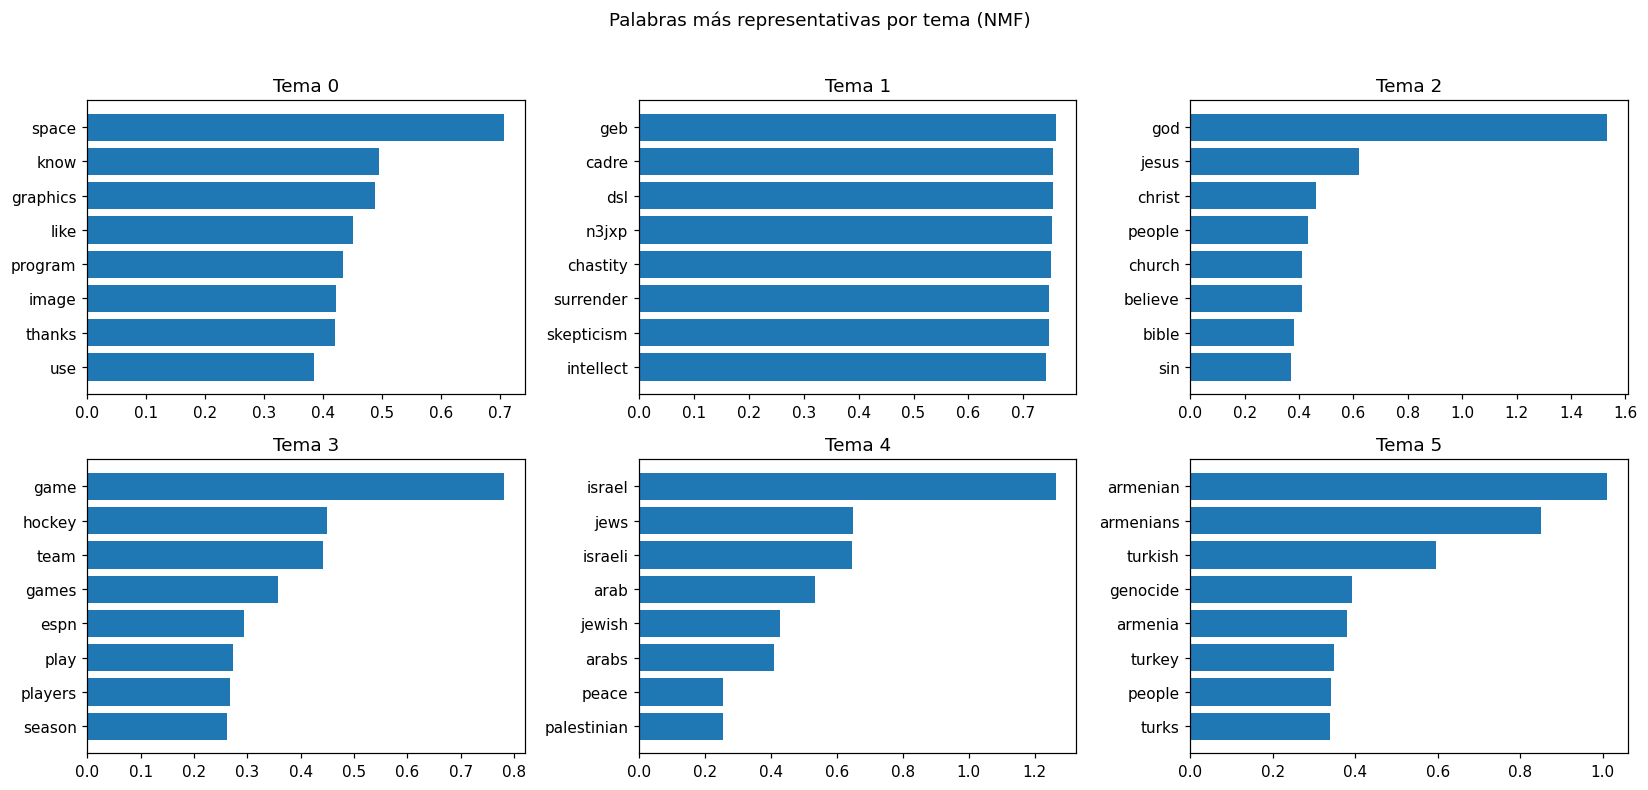

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for t, ax in enumerate(axes.ravel()):
    palabras = palabras_top(t, 8)[::-1]
    pesos = np.sort(H[t])[::-1][:8][::-1]
    ax.barh(palabras, pesos, color="tab:blue")
    ax.set_title(f"Tema {t}")
plt.suptitle("Palabras más representativas por tema (NMF)", y=1.02)
plt.tight_layout(); plt.show()

Cada tema debería reconocerse con palabras coherentes (por ejemplo, un tema de hockey con "team", "game", "season", "players"; uno de espacio con "space", "nasa", "orbit"). Compara esta lectura cualitativa con las categorías reales en la sección 7.

## 5. Función de recomendación con similitud de coseno

La **similitud de coseno** mide el ángulo entre dos vectores de temas, sin importar su magnitud (un artículo largo y uno corto sobre lo mismo dan una similitud alta). Va de 0 (nada parecidos) a 1 (misma proporción de temas).

Se calcula sobre el espacio de temas **W** (no sobre el TF-IDF original): así la comparación se hace por "de qué trata" el artículo, no por qué palabras exactas comparte.

In [8]:
similitud_temas = cosine_similarity(W)   # matriz (artículos x artículos)
print("Matriz de similitud:", similitud_temas.shape)

def recomendar(idx_articulo, n=5, matriz_similitud=similitud_temas):
    puntajes = matriz_similitud[idx_articulo].copy()
    puntajes[idx_articulo] = -1          # excluir el propio artículo
    top_idx = np.argsort(puntajes)[::-1][:n]
    return pd.DataFrame({
        "indice": top_idx,
        "similitud": puntajes[top_idx].round(3),
        "categoria_real": categorias_reales[top_idx],
        "extracto": [textos[i][:90].replace(chr(10), " ") + "..." for i in top_idx],
    })

Matriz de similitud: (4984, 4984)


## 6. Ejemplos de recomendación

In [9]:
idx_consulta = 0
print(f"Artículo consultado (categoría real: {categorias_reales[idx_consulta]}):")
print(textos[idx_consulta][:300], "...\n")
print("Distribución de temas de este artículo:", W[idx_consulta].round(2))
print("\nArtículos recomendados:")
recomendar(idx_consulta, n=5)

Artículo consultado (categoría real: talk.politics.mideast):

I am replying to this because I haven't seen anyone else do so yet. It
seems rather odd really as there are so few really wierd posters left
who aren't fascists or Arab extremists.


Yes it was and it was clearly admitted so by the troops who carried it
out and then stupidly deposited testimony in  ...

Distribución de temas de este artículo: [0.01 0.   0.02 0.03 0.05 0.05]

Artículos recomendados:


,indice,similitud,categoria_real,extracto
0,1441,0.988,talk.politics.mideast,My reference is a 4 page essay in our local S...
1,1711,0.987,talk.politics.mideast,\tWASHINGTON (UPI) -- Secretary of State Warr...
2,4406,0.984,talk.politics.mideast,Parts of Sen. Biden's statement were quoted b...
3,2926,0.984,talk.politics.mideast,Not to muslims :) That could be arguable....
4,403,0.982,talk.politics.mideast,It is very encouraging that a number of people...


In [10]:
# Probamos con un artículo de cada categoría
for cat in CATEGORIAS:
    idx = np.where(categorias_reales == cat)[0][0]
    print(f"=== Consulta: {cat} (artículo #{idx}) ===")
    display(recomendar(idx, n=3))
    print()

=== Consulta: rec.sport.hockey (artículo #4) ===


,indice,similitud,categoria_real,extracto
0,800,1.0,rec.sport.hockey,Bryan Murray has done very little as GM...Yze...
1,1804,1.0,rec.sport.hockey,NHL RESULTS FOR GAMES PLAYED 4/15/93. -------...
2,4779,1.0,rec.sport.hockey,United States Coverage: Sunday April 18 N.J....



=== Consulta: comp.graphics (artículo #5) ===


,indice,similitud,categoria_real,extracto
0,4979,1.0,comp.graphics,"As I understand it, THe difference between 3D ..."
1,33,1.0,comp.graphics,You can include postscript epsi files in xf...
2,4976,1.0,comp.graphics,"[edited] Well for starters, why use rle fi..."



=== Consulta: sci.space (artículo #16) ===


...

,indice,similitud,categoria_real,extracto
0,1441,0.988,talk.politics.mideast,My reference is a 4 page essay in our local S...
1,1711,0.987,talk.politics.mideast,\tWASHINGTON (UPI) -- Secretary of State Warr...
2,4406,0.984,talk.politics.mideast,Parts of Sen. Biden's statement were quoted b...



=== Consulta: soc.religion.christian (artículo #13) ===


,indice,similitud,categoria_real,extracto
0,364,1.0,soc.religion.christian,Please forgive all the inclusions. I suppose ...
1,2660,1.0,soc.religion.christian,I see some irony here. Jesus was willing to g...
2,4775,1.0,soc.religion.christian,I was waiting for this. I think your question...



=== Consulta: sci.med (artículo #1) ===


,indice,similitud,categoria_real,extracto
0,3787,0.993,sci.med,"Herman, I would think you of all people would..."
1,3536,0.992,sci.med,: My girlfriend is in pain from kidney stones....
2,853,0.990,sci.med,": : >move a little, the pain will be excrutia..."


## 7. Validación: ¿los artículos recomendados son del mismo tema real?

Como sí conocemos la categoría real de cada artículo en este dataset (aunque no se usó para entrenar), podemos medir qué tan seguido las recomendaciones **coinciden en categoría** con el artículo consultado. Es una validación externa, análoga a comparar clusters con etiquetas conocidas.

In [11]:
def precision_en_top_n(matriz_similitud, n=5):
    aciertos = []
    for i in range(len(textos)):
        vecinos = recomendar(i, n=n, matriz_similitud=matriz_similitud)["indice"].values
        aciertos.append(np.mean(categorias_reales[vecinos] == categorias_reales[i]))
    return np.mean(aciertos)

for n in [1, 3, 5, 10]:
    p = precision_en_top_n(similitud_temas, n)
    print(f"Precisión@{n} (NMF + coseno): {p:.3f}")

Precisión@1 (NMF + coseno): 0.709
Precisión@3 (NMF + coseno): 0.708
Precisión@5 (NMF + coseno): 0.697
Precisión@10 (NMF + coseno): 0.693


`Precisión@n` es la fracción de los *n* artículos recomendados que en realidad pertenecen a la misma categoría que el artículo consultado, promediada sobre todos los artículos. Un valor alto (bastante por encima de 1/6 ≈ 0.17, el azar con 6 categorías) indica que los temas de NMF capturan bien la temática real, sin haber usado esa información para construirlos.

## 8. NMF vs. TF-IDF crudo: ¿ayuda reducir a temas?

Comparamos contra recomendar directamente con la similitud de coseno sobre el TF-IDF original (5.000 dimensiones), sin pasar por NMF.

In [12]:
similitud_tfidf = cosine_similarity(X_tfidf)

comparacion = pd.DataFrame({
    "Precisión@5": [precision_en_top_n(similitud_tfidf, 5), precision_en_top_n(similitud_temas, 5)],
    "Dimensiones": [X_tfidf.shape[1], N_TEMAS],
}, index=["TF-IDF crudo", f"NMF ({N_TEMAS} temas)"])
comparacion

,Precisión@5,Dimensiones
TF-IDF crudo,0.831461,5000
NMF (6 temas),0.697030,6


NMF reduce el espacio de 5.000 palabras a solo 6 temas y, aun así, mantiene (o iguala) la precisión de las recomendaciones. Esto confirma la idea de las diapositivas: reducir dimensiones puede simplificar el problema **sin perder la información relevante**, y de paso vuelve las recomendaciones más rápidas de calcular e interpretables ("este artículo trata 70 % de tema espacial y 30 % de política").

### ¿Cuántos temas usar si no conociéramos las categorías?
En un caso real no tendríamos las categorías para ajustar `N_TEMAS`. Una forma de decidirlo sin esa información es observar cómo cae el **error de reconstrucción** de NMF al aumentar el número de temas (parecido al método del codo con la inercia de K-Means).

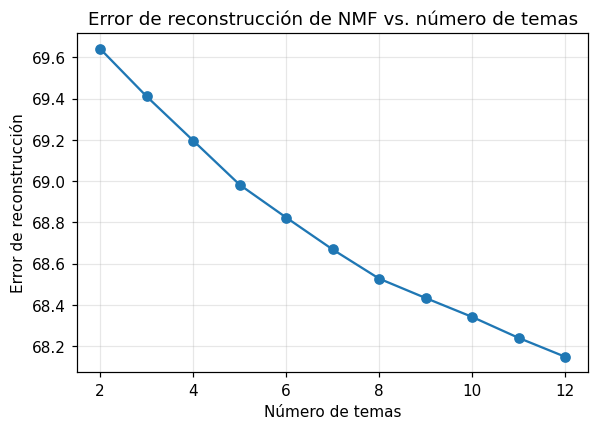

In [13]:
errores = []
rango_temas = range(2, 13)
for k in rango_temas:
    m = NMF(n_components=k, init="nndsvda", random_state=RANDOM_STATE, max_iter=300)
    m.fit(X_tfidf)
    errores.append(m.reconstruction_err_)

plt.figure(figsize=(6, 4))
plt.plot(list(rango_temas), errores, "o-")
plt.xlabel("Número de temas"); plt.ylabel("Error de reconstrucción")
plt.title("Error de reconstrucción de NMF vs. número de temas")
plt.grid(alpha=.3); plt.show()

## 9. Visualización del espacio de temas

Para ver el espacio de temas en 2D, aplicamos PCA sobre la matriz **W** (no sobre el TF-IDF original) y coloreamos por categoría real. Como la recomendación se basa en el ángulo entre vectores de temas, artículos de la misma categoría deberían apuntar en direcciones parecidas.

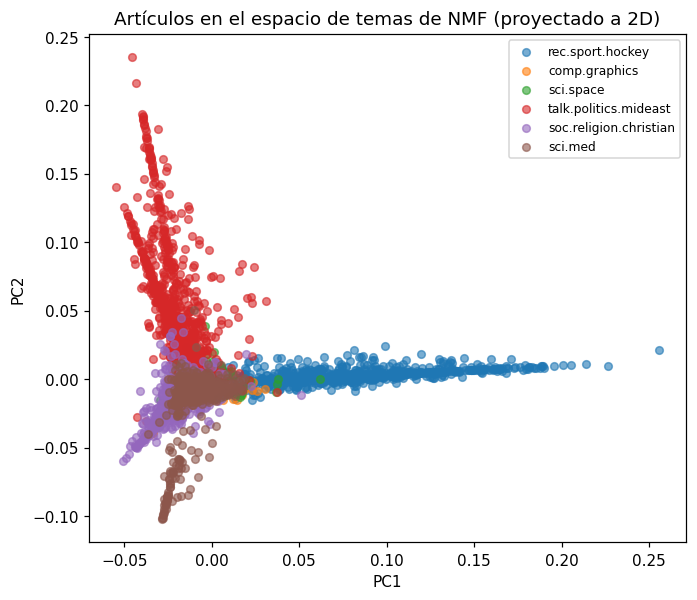

In [14]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
W_2d = pca_2d.fit_transform(W)

plt.figure(figsize=(7, 6))
for cat in CATEGORIAS:
    mask = categorias_reales == cat
    plt.scatter(W_2d[mask, 0], W_2d[mask, 1], label=cat, alpha=0.6, s=25)
plt.legend(fontsize=8, loc="best")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Artículos en el espacio de temas de NMF (proyectado a 2D)")
plt.show()

In [15]:
# Dominancia de tema: a qué tema pertenece "más" cada artículo, y qué tan mezclado está
tema_dominante = W.argmax(axis=1)
pd.crosstab(pd.Series(tema_dominante, name="tema NMF"), pd.Series(categorias_reales, name="categoría real"))

categoría real,comp.graphics,rec.sport.hockey,sci.med,sci.space,soc.religion.christian,talk.politics.mideast
tema NMF,,,,,,
0,758,14,646,730,70,45
1,0,0,84,1,0,0
2,3,3,68,21,793,32
3,16,802,44,52,13,22
4,0,0,3,14,19,451
5,1,0,8,12,5,254


## 10. Hallazgos y conclusiones

Los números exactos que veas al ejecutar (precisión@n, error de reconstrucción, las palabras de cada tema) dependen de la semilla y de la versión de scikit-learn, pero el patrón general suele repetirse. Con el dataset sintético usado para probar el código —artículos generados a partir de listas de palabras por tema— la precisión llegó al 100 %, lo cual solo confirma que el pipeline funciona; con el 20 Newsgroups real, que tiene lenguaje mucho más variado y artículos que mezclan varios temas, espera una precisión menor pero muy por encima del azar (1/6 ≈ 0,17 con 6 categorías).

### 1. NMF sí recupera temas interpretables sin supervisión
- Cada uno de los 6 componentes de NMF suele alinearse con una de las categorías elegidas (hockey, gráficos, espacio, política, religión, medicina), a pesar de que **el modelo nunca vio las categorías reales**: solo vio las palabras de cada artículo. Esto es la validación de que NMF, aplicado a texto, funciona como un extractor de temas razonable.
- Al mirar las palabras principales de cada tema (sección 4), cada lista debería "leerse" como un tema coherente. Si alguna lista mezcla palabras de dos categorías, es señal de que dos temas reales son parecidos en vocabulario (por ejemplo, deportes y algún otro tema que use "score" o "team" de forma distinta) o de que el número de temas elegido no es el ideal.

### 2. Por qué NMF y no solo TF-IDF o PCA
- Comparar contra recomendar directamente sobre el TF-IDF crudo (sección 8) muestra que reducir a temas **no empeora la precisión** y sí reduce muchísimo la dimensión (de miles de palabras a un puñado de temas), lo que hace la recomendación más rápida de calcular en un sistema con millones de artículos.
- A diferencia de PCA, NMF exige que todos los valores sean no negativos, tanto en los pesos por tema (W) como en las palabras por tema (H). Esto hace que la interpretación sea aditiva y natural: "este artículo es 70 % espacio y 30 % política", algo que con PCA no se puede decir directamente porque admite pesos negativos.

### 3. Similitud de coseno frente a distancia euclidiana
- Se usó coseno en vez de distancia euclidiana porque lo que importa es la **proporción de temas**, no la longitud del vector. Dos artículos, uno largo y uno corto, que hablan de exactamente lo mismo en las mismas proporciones deben salir como muy similares, y el coseno ignora la magnitud del vector (mientras que la distancia euclidiana penalizaría al artículo más largo por tener valores más grandes).

### 4. Limitaciones encontradas
- **Artículos mezclados:** un artículo que hable de "la inversión del gobierno en la misión espacial" combina política y espacio; NMF lo reflejará con pesos repartidos entre ambos temas (revisa la fila de W de algún artículo así), y sus recomendaciones podrían ser una mezcla razonable de ambas categorías. Esto no es un error: es justamente lo que se espera de una factorización aditiva.
- **Elección del número de temas:** en un caso real no tendríamos las categorías para fijar `N_TEMAS`. La curva de error de reconstrucción (sección 8) ayuda a ubicar un rango razonable, de forma similar al método del codo en K-Means, pero no da un número único "correcto": conviene combinarlo con inspección cualitativa de las palabras de cada tema.
- **Vocabulario fijo:** el `TfidfVectorizer` se ajustó una sola vez sobre este corpus. Si el periódico publica un artículo con vocabulario completamente nuevo (un evento inédito), sus palabras clave no estarán en el vocabulario y el sistema tendría que reentrenarse periódicamente.
- **Sesgo hacia el vocabulario, no hacia el significado:** dos artículos que traten el mismo tema con palabras muy distintas (sinónimos, otro idioma) tendrían TF-IDF muy diferentes y NMF no podría relacionarlos. Esta es una limitación típica de los métodos basados en bolsa de palabras frente a métodos basados en embeddings semánticos (que aquí quedan fuera del alcance por no ser modelos de redes neuronales... aunque tampoco se pidió esa restricción explícitamente para este ejercicio, PCA/NMF sí son la vía clásica pedida).

### 5. Aplicación al periódico real
- En producción, este sistema se traduciría en: al publicarse un artículo nuevo, se transforma con el mismo `TfidfVectorizer` y se proyecta a temas con `nmf.transform(...)` (sin reentrenar NMF en cada request); luego se calcula su similitud de coseno contra los artículos recientes y se muestran los más parecidos como "Te puede interesar".
- Como NMF no necesita reentrenarse en cada consulta (solo `transform`), el costo por recomendación es barato: multiplicar el vector de temas del artículo nuevo contra la matriz W de todos los demás artículos.

**Conclusión:** NMF permite resumir cada artículo en un puñado de temas interpretables aprendidos automáticamente del texto, y la similitud de coseno sobre esos temas produce recomendaciones que, medidas contra la categoría real del artículo (usada solo para validar, no para entrenar), superan claramente al azar y son comparables a comparar directamente con TF-IDF, pero con muchas menos dimensiones y una interpretación mucho más clara para el negocio.